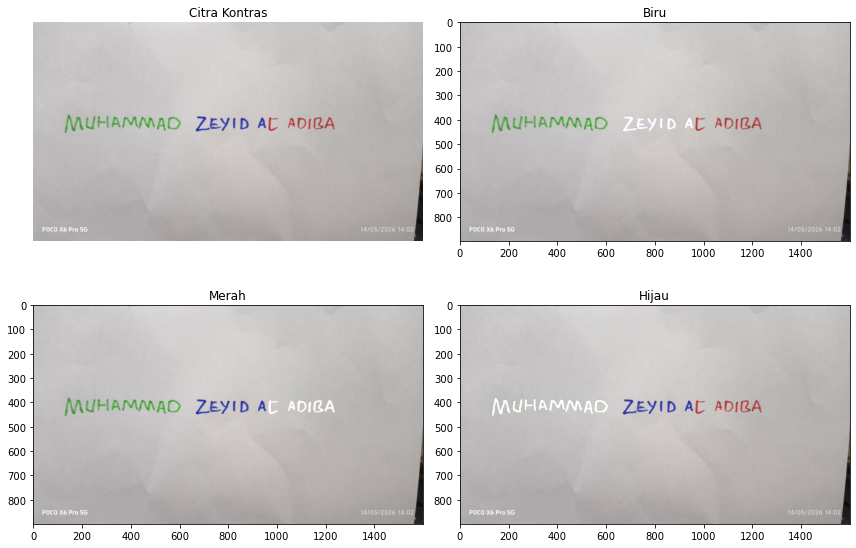

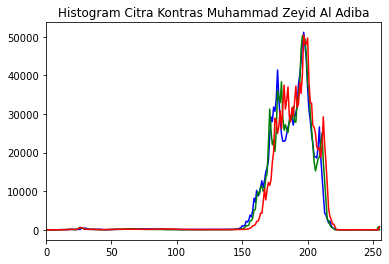

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Muhammad_Zeyid_Al_Adiba.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_blue, upper_blue = np.array([100, 50, 50]), np.array([130, 255, 255])
lower_red1, upper_red1 = np.array([0, 50, 50]), np.array([10, 255, 255])
lower_red2, upper_red2 = np.array([170, 50, 50]), np.array([180, 255, 255])
lower_green, upper_green = np.array([35, 50, 50]), np.array([85, 255, 255])

mask_b = cv2.inRange(img_hsv, lower_blue, upper_blue)
mask_g = cv2.inRange(img_hsv, lower_green, upper_green)
mask_r = cv2.bitwise_or(cv2.inRange(img_hsv, lower_red1, upper_red1), cv2.inRange(img_hsv, lower_red2, upper_red2))

res_b = cv2.bitwise_or(img_rgb, img_rgb, mask=cv2.bitwise_not(mask_b))
res_r = cv2.bitwise_or(img_rgb, img_rgb, mask=cv2.bitwise_not(mask_r))
res_g = cv2.bitwise_or(img_rgb, img_rgb, mask=cv2.bitwise_not(mask_g))

res_b[mask_b > 0] = [255, 255, 255]
res_r[mask_r > 0] = [255, 255, 255]
res_g[mask_g > 0] = [255, 255, 255]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Kontras')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(res_b)
plt.title('Biru')
plt.axis('on')

plt.subplot(2, 2, 3)
plt.imshow(res_r)
plt.title('Merah')
plt.axis('on')

plt.subplot(2, 2, 4)
plt.imshow(res_g)
plt.title('Hijau')
plt.axis('on')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
colors = ('b', 'g', 'r')
for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
plt.title('Histogram Citra Kontras Muhammad Zeyid Al Adiba')
plt.xlim([0, 256])
plt.show()

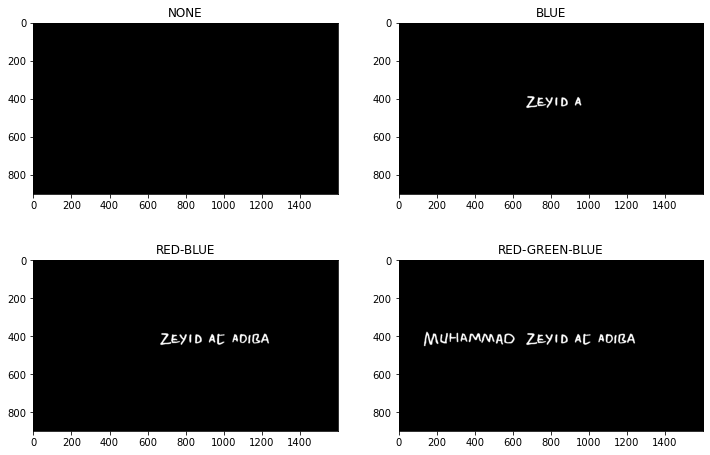

In [6]:
none_bin = np.zeros(img.shape[:2], dtype="uint8")
blue_bin = mask_b
red_blue_bin = cv2.bitwise_or(mask_r, mask_b)
rgb_bin = cv2.bitwise_or(cv2.bitwise_or(mask_r, mask_b), mask_g)

titles_f = ['NONE', 'BLUE', 'RED-BLUE', 'RED-GREEN-BLUE']
results_f = [none_bin, blue_bin, red_blue_bin, rgb_bin]

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(results_f[i], cmap='gray')
    plt.title(titles_f[i])
    plt.axis('on')
plt.show()

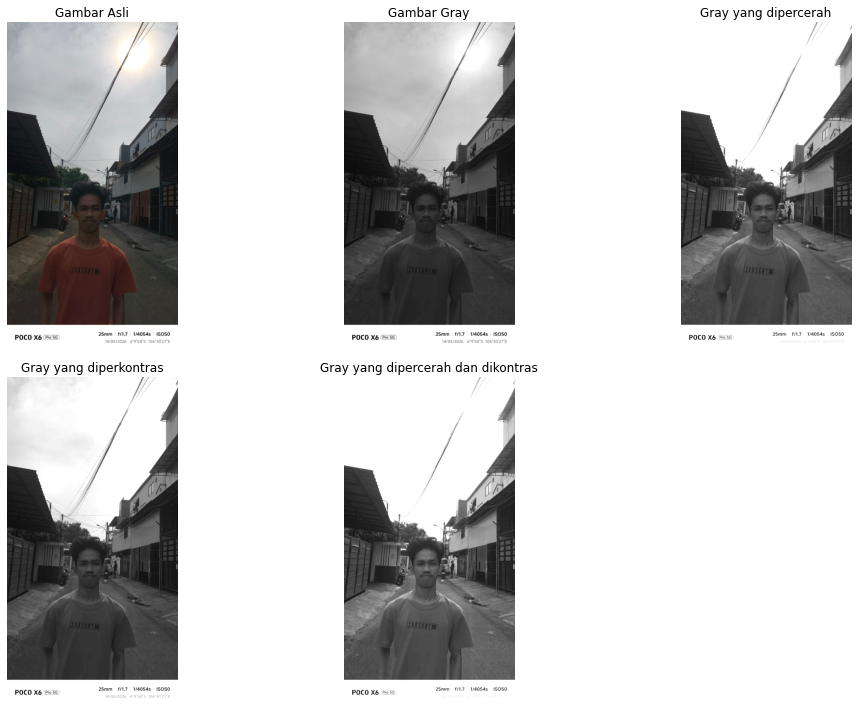

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_backlight = cv2.imread('Backlight_Zeyid.jpeg')
img_rgb = cv2.cvtColor(img_backlight, cv2.COLOR_BGR2RGB)

img_gray = cv2.cvtColor(img_backlight, cv2.COLOR_BGR2GRAY)

alpha_bright = 1.5
beta_bright = 30
img_brightened = cv2.convertScaleAbs(img_gray, alpha=alpha_bright, beta=beta_bright)

alpha_contrast = 1.3
img_contrasted = cv2.convertScaleAbs(img_gray, alpha=alpha_contrast, beta=0)

img_final = cv2.convertScaleAbs(img_gray, alpha=1.6, beta=40)

titles = ['Gambar Asli', 'Gambar Gray', 'Gray yang dipercerah', 'Gray yang diperkontras', 'Gray yang dipercerah dan dikontras']
images = [img_rgb, img_gray, img_brightened, img_contrasted, img_final]

plt.figure(figsize=(15, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    if i == 0:
        plt.imshow(images[i])
    else:
        plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()